# B1 v2 — eRisk: Mental Health Detection with MentalRoBERTa
## Research Protocol 001 v2

Reddit 2017–2022. MentalRoBERTa embeddings (D=768) + relative temporal features + behavioral patterns.

**Key changes from v1:** MentalRoBERTa (D=768), relative temporal encoding, behavioral features, top-down hierarchy.

### Pipeline
1. Behavioral features analysis (no embeddings needed)
2. Static embedding baseline (mean MentalRoBERTa)
3. Recency-weighted temporal embedding
4. Top-down region analysis (CVX, L3→L2)
5. Feature ablation + classification
6. Early detection (AUC@k%)

In [1]:
import numpy as np, pandas as pd, json, math, time, itertools
from pathlib import Path
from scipy import stats
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                             recall_score, classification_report)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt, seaborn as sns
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.figsize': (14, 5), 'figure.dpi': 120, 'font.size': 11})
SEED = 42; np.random.seed(SEED)
N_BOOTSTRAP = 1000
colors = {'depression': '#e74c3c', 'control': '#2ecc71'}

def compute_metrics(y_true, y_prob, y_pred):
    return {'AUC': roc_auc_score(y_true, y_prob), 'F1': f1_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred)}

def bootstrap_ci(y_true, y_prob, y_pred, n=N_BOOTSTRAP):
    rng = np.random.RandomState(SEED)
    boot = {'AUC': [], 'F1': [], 'Precision': [], 'Recall': []}
    for _ in range(n):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2: continue
        boot['AUC'].append(roc_auc_score(y_true[idx], y_prob[idx]))
        boot['F1'].append(f1_score(y_true[idx], y_pred[idx], zero_division=0))
        boot['Precision'].append(precision_score(y_true[idx], y_pred[idx], zero_division=0))
        boot['Recall'].append(recall_score(y_true[idx], y_pred[idx]))
    return {k: {'mean': np.mean(v), 'lo': np.percentile(v, 2.5), 'hi': np.percentile(v, 97.5)}
            for k, v in boot.items()}

def train_eval(X_tr, y_tr, X_te, y_te, label=''):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    clf = RandomForestClassifier(n_estimators=300, max_depth=15,
                                  class_weight='balanced', random_state=SEED)
    clf.fit(X_tr_s, y_tr)
    yp = clf.predict_proba(X_te_s)[:,1]; ypred = clf.predict(X_te_s)
    m = compute_metrics(y_te, yp, ypred)
    print(f'  {label}: AUC={m["AUC"]:.4f} F1={m["F1"]:.4f} P={m["Precision"]:.4f} R={m["Recall"]:.4f}')
    return m, clf, yp, ypred

print('Setup OK')

Setup OK


## 1. Behavioral Feature Analysis
Using posting patterns only — no embeddings, no CVX. This tests whether **behavioral signals** (posting gaps, frequency, circadian patterns) alone can discriminate depression.

In [2]:
# Load behavioral features (one row per user, tiny file)
behav = pd.read_parquet(Path('../data/embeddings/erisk_mental_behavioral.parquet'))
print(f'Behavioral features: {len(behav)} users')
print(behav.columns.tolist())

# Load split info from embeddings parquet (just metadata columns)
split_df = pd.read_parquet(Path('../data/embeddings/erisk_mental_embeddings.parquet'),
    columns=['user_id', 'split', 'label']).groupby('user_id').first().reset_index()
behav = behav.merge(split_df[['user_id', 'split']], on='user_id', how='left')

print(f'\nUsers per split:')
for s, g in behav.groupby('split'):
    nd = (g['label']=='depression').sum()
    print(f'  {s:>5}: {nd} dep + {len(g)-nd} ctrl')

Behavioral features: 2285 users
['user_id', 'label', 'n_posts', 'span_days', 'mean_gap', 'std_gap', 'max_gap', 'median_gap', 'gap_cv', 'gap_trend', 'night_ratio', 'evening_ratio', 'burst_count']



Users per split:
   test: 98 dep + 1300 ctrl
  train: 104 dep + 612 ctrl
    val: 31 dep + 140 ctrl


In [3]:
# Feature discriminability
feat_cols = ['mean_gap', 'std_gap', 'max_gap', 'median_gap', 'gap_cv',
             'gap_trend', 'night_ratio', 'evening_ratio', 'burst_count',
             'n_posts', 'span_days']

print('Feature Discriminability (Mann-Whitney U):')
print(f'{"Feature":>15} {"dep_mean":>10} {"ctrl_mean":>10} {"p":>10} {"d":>8}')
print('-' * 60)
for col in feat_cols:
    dep = behav[behav['label']=='depression'][col].dropna()
    ctrl = behav[behav['label']=='control'][col].dropna()
    if len(dep) < 5 or len(ctrl) < 5: continue
    _, p = stats.mannwhitneyu(dep, ctrl, alternative='two-sided')
    d = (dep.mean()-ctrl.mean()) / np.sqrt((dep.std()**2+ctrl.std()**2)/2) if (dep.std()+ctrl.std()) > 0 else 0
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f'{col:>15} {dep.mean():>10.2f} {ctrl.mean():>10.2f} {p:>10.4f} {d:>7.3f} {sig}')

Feature Discriminability (Mann-Whitney U):
        Feature   dep_mean  ctrl_mean          p        d
------------------------------------------------------------
       mean_gap  446685.62  380546.08     0.0013   0.063 **
        std_gap 1322499.23 1167487.14     0.0013   0.059 **
        max_gap 12426595.62 11616730.99     0.0217   0.041 *
     median_gap   93284.55   48174.41     0.8603   0.100 
         gap_cv       4.18       4.32     0.2105  -0.038 
      gap_trend   -4193.73   -7124.46     0.3951   0.012 
    night_ratio       0.31       0.22     0.0000   0.534 ***
  evening_ratio       0.30       0.30     0.7137   0.053 
    burst_count     381.91     602.96     0.0000  -0.438 ***
        n_posts     396.61     617.34     0.0000  -0.436 ***
      span_days     655.11     708.79     0.9140  -0.076 


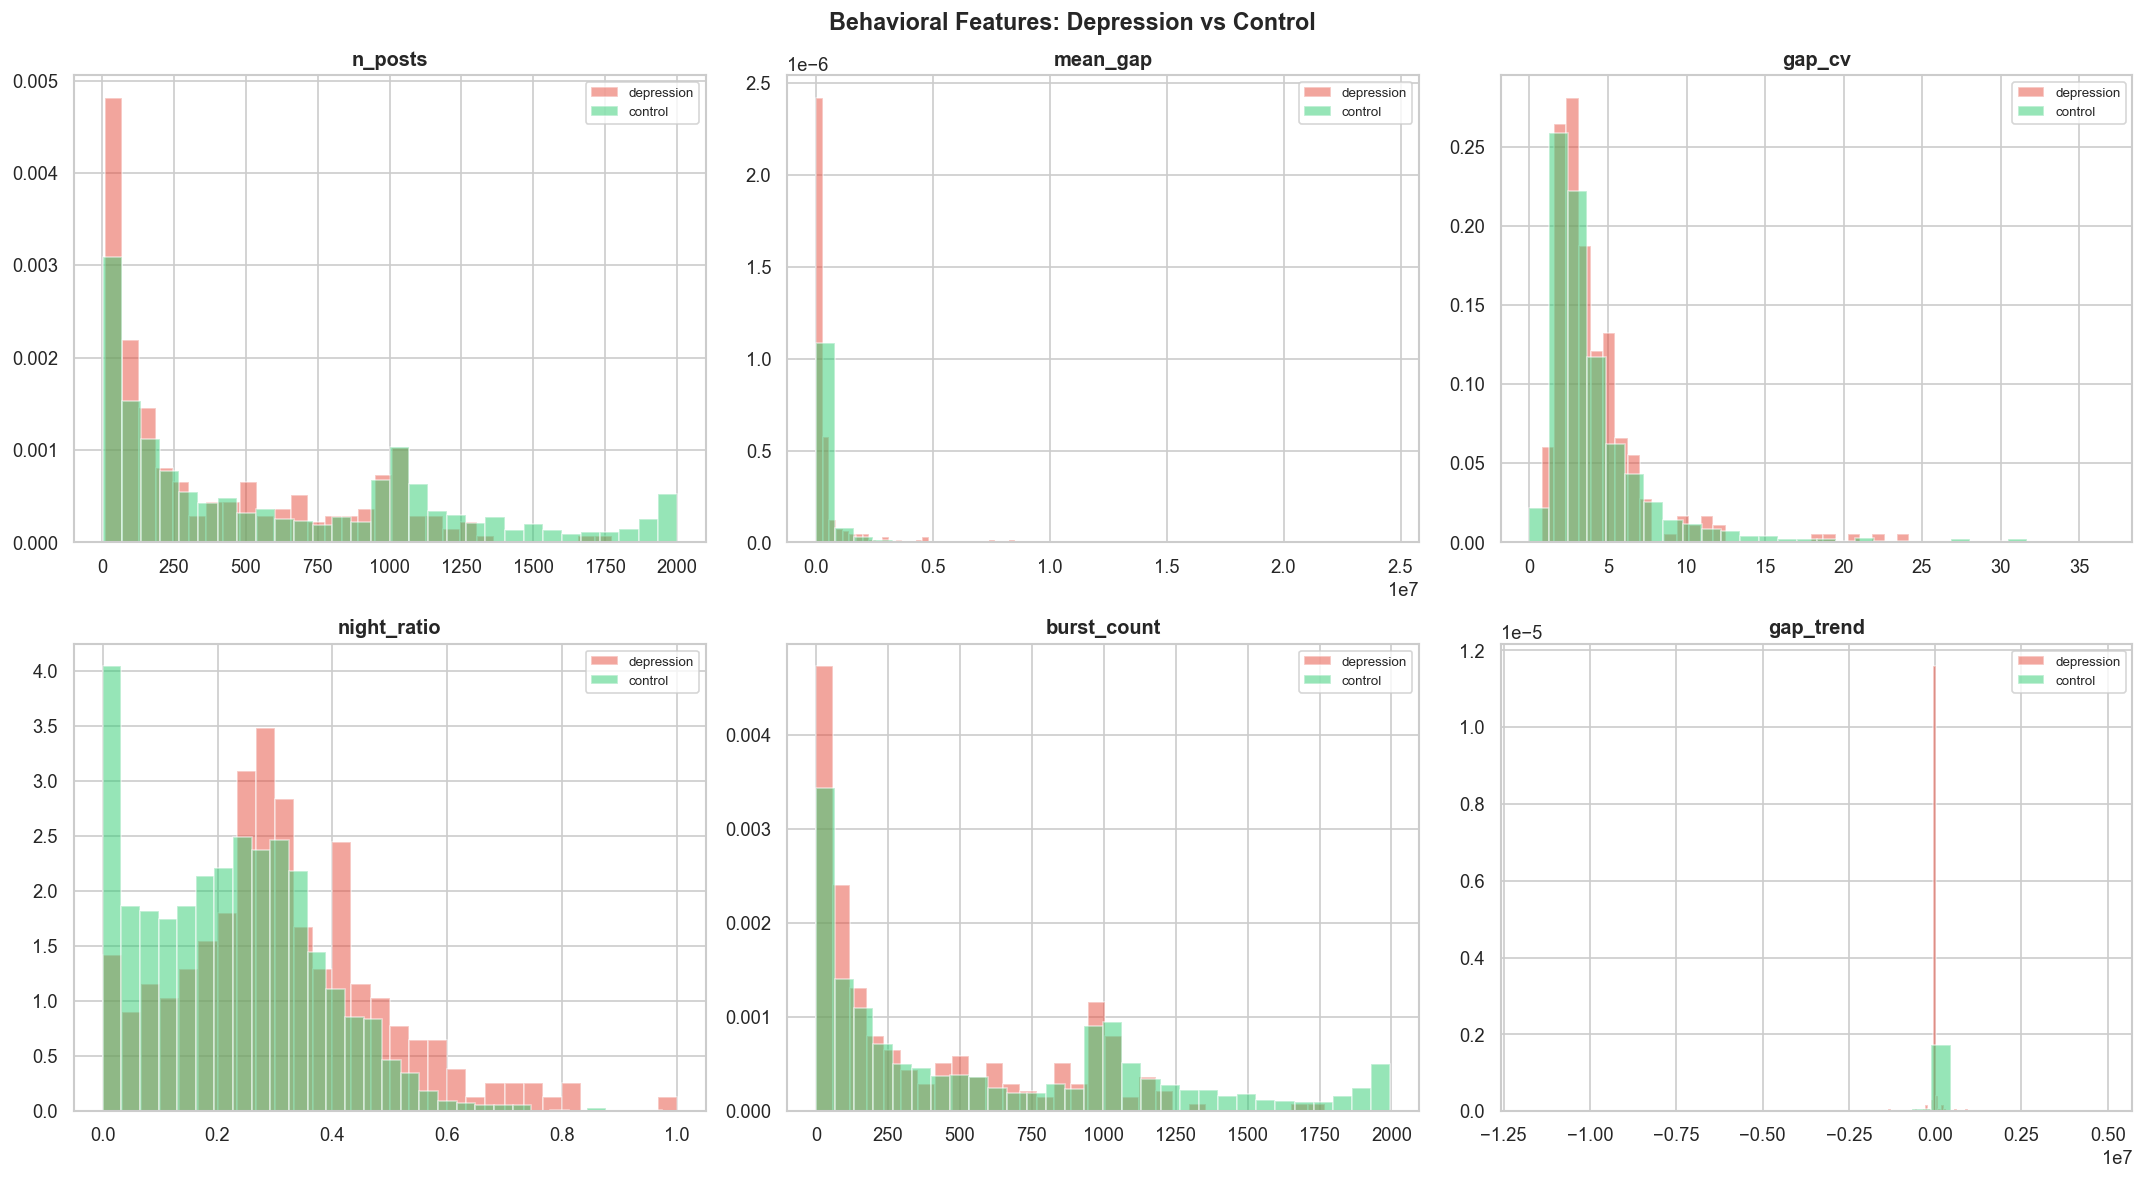

In [4]:
# Visualize top behavioral features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, col in zip(axes.flat, ['n_posts', 'mean_gap', 'gap_cv', 'night_ratio', 'burst_count', 'gap_trend']):
    for lab, c in colors.items():
        vals = behav[behav['label']==lab][col].dropna()
        ax.hist(vals, bins=30, alpha=0.5, color=c, label=lab, density=True)
    ax.set_title(col, fontweight='bold'); ax.legend(fontsize=8)
fig.suptitle('Behavioral Features: Depression vs Control', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [5]:
# Classify with behavioral features only
tr = behav[behav['split']=='train']; te = behav[behav['split']=='test']
X_tr = tr[feat_cols].fillna(0).values; y_tr = (tr['label']=='depression').astype(int).values
X_te = te[feat_cols].fillna(0).values; y_te = (te['label']=='depression').astype(int).values

results = {}
results['behavioral'], _, _, _ = train_eval(X_tr, y_tr, X_te, y_te, 'Behavioral only')

  Behavioral only: AUC=0.6432 F1=0.0200 P=0.5000 R=0.0102


## 2. Embedding Baselines (MentalRoBERTa)

Two aggregation strategies:
- **Static**: Mean embedding per user (ignores temporal order)
- **Recency-weighted**: Weighted mean where recent posts have higher weight ($w_i = t_{rel,i}$)

In [6]:
# Load embeddings (large file — may take 1-2 min)
print('Loading MentalRoBERTa embeddings...')
t0 = time.perf_counter()
df = pd.read_parquet(Path('../data/embeddings/erisk_mental_embeddings.parquet'))
emb_cols = [c for c in df.columns if c.startswith('emb_')]
DIM = len(emb_cols)
elapsed = time.perf_counter() - t0
print(f'Loaded {len(df):,} posts, {df["user_id"].nunique()} users, D={DIM} in {elapsed:.1f}s')

# Ensure sorted
df = df.sort_values(['user_id', 'timestamp']).reset_index(drop=True)

# User-level split/label lookup
user_info = df.groupby('user_id')[['split','label']].first()

Loading MentalRoBERTa embeddings...


Loaded 1,359,188 posts, 2285 users, D=768 in 4.5s


In [7]:
# Static baseline: mean embedding per user
print('Computing mean embeddings per user...')
user_mean = df.groupby('user_id')[emb_cols].mean()

tr_uids = user_info[user_info['split']=='train'].index
te_uids = user_info[user_info['split']=='test'].index

X_tr = user_mean.loc[user_mean.index.isin(tr_uids)].values
y_tr = (user_info.loc[user_mean.index[user_mean.index.isin(tr_uids)], 'label']=='depression').astype(int).values
X_te = user_mean.loc[user_mean.index.isin(te_uids)].values
y_te = (user_info.loc[user_mean.index[user_mean.index.isin(te_uids)], 'label']=='depression').astype(int).values

results['static_mentalroberta'], _, _, _ = train_eval(X_tr, y_tr, X_te, y_te, 'Static MentalRoBERTa')

Computing mean embeddings per user...


  Static MentalRoBERTa: AUC=0.9009 F1=0.4571 P=0.7619 R=0.3265


In [8]:
# Recency-weighted embedding: w_i = t_rel_i (more weight to recent posts)
print('Computing recency-weighted embeddings...')

weights = (df['t_rel'].values + 0.01).reshape(-1, 1)  # (N, 1)
weighted_embs = df[emb_cols].values * weights
df['_w'] = weights.ravel()

user_wsum = pd.DataFrame(weighted_embs, index=df.index, columns=emb_cols)
user_wsum['user_id'] = df['user_id'].values
user_wsum = user_wsum.groupby('user_id')[emb_cols].sum()
user_wtotal = df.groupby('user_id')['_w'].sum()
user_wmean = user_wsum.div(user_wtotal, axis=0)
df.drop(columns=['_w'], inplace=True)
del weighted_embs, user_wsum, user_wtotal

X_tr = user_wmean.loc[user_wmean.index.isin(tr_uids)].values
X_te = user_wmean.loc[user_wmean.index.isin(te_uids)].values

results['temporal_mentalroberta'], _, _, _ = train_eval(X_tr, y_tr, X_te, y_te, 'Temporal MentalRoBERTa')

Computing recency-weighted embeddings...


  Temporal MentalRoBERTa: AUC=0.9095 F1=0.4429 P=0.7381 R=0.3163


In [9]:
# Combined: embedding + behavioral
print('Computing combined features...')
behav_indexed = behav.set_index('user_id')[feat_cols].fillna(0)

def combine_features(emb_df, behav_df, uids):
    emb_vals = emb_df.loc[emb_df.index.isin(uids)].values
    b_vals = behav_df.loc[emb_df.index[emb_df.index.isin(uids)]].values
    return np.hstack([emb_vals, b_vals])

X_tr = combine_features(user_wmean, behav_indexed, tr_uids)
X_te = combine_features(user_wmean, behav_indexed, te_uids)

results['temporal+behavioral'], _, _, _ = train_eval(X_tr, y_tr, X_te, y_te, 'Temporal + Behavioral')

Computing combined features...


  Temporal + Behavioral: AUC=0.9068 F1=0.4317 P=0.7317 R=0.3061


## 3. Top-Down Region Analysis (CVX)

Ingest posts into ChronosVector, discover regions top-down (L3 → L2), and extract region distribution features.

In [10]:
import chronos_vector as cvx

# Cap posts per user for tractable ingestion
MAX_POSTS = 200
df_capped = df.groupby('user_id').head(MAX_POSTS).reset_index(drop=True)

# Day-scale relative timestamps for CVX
df_capped['ts_int'] = (df_capped['t_rel'] * 1000).astype(int)  # scale to 0-1000

index = cvx.TemporalIndex(m=16, ef_construction=200, ef_search=100)
uid_map = {uid: i for i, uid in enumerate(df_capped['user_id'].unique())}

print(f'Ingesting {len(df_capped):,} posts (D={DIM}, max {MAX_POSTS}/user)...')
t0 = time.perf_counter()
for _, row in df_capped.iterrows():
    index.insert(entity_id=uid_map[row['user_id']],
                 timestamp=int(row['ts_int']),
                 vector=row[emb_cols].values.astype(np.float32).tolist())
elapsed = time.perf_counter() - t0
print(f'Done in {elapsed:.1f}s ({len(df_capped)/elapsed:,.0f} pts/sec)')

Ingesting 344,696 posts (D=768, max 200/user)...


Done in 1094.1s (315 pts/sec)


In [11]:
# Top-down region discovery
for lv in [3, 2, 1]:
    r = index.regions(level=lv)
    print(f'Level {lv}: {len(r)} regions')

# Extract region distribution at L3 (coarsest — ~60-80 regions)
L3_regions = index.regions(level=3)
K3 = len(L3_regions)
print(f'\nUsing L3: K={K3} coarse regions')

# Compute region distribution per user (proportion of posts in each region)
from sklearn.metrics.pairwise import cosine_distances

hub_vecs = np.array([v for _, v, _ in L3_regions])

print('Assigning posts to L3 regions...')
# Process in chunks to avoid memory explosion
chunk_size = 50000
all_assignments = []
for start in range(0, len(df_capped), chunk_size):
    chunk = df_capped.iloc[start:start+chunk_size]
    embs = chunk[emb_cols].values.astype(np.float32)
    dists = cosine_distances(embs, hub_vecs)
    all_assignments.extend(np.argmin(dists, axis=1).tolist())
df_capped['region_l3'] = all_assignments

# Per-user region distribution
user_region_dist = df_capped.groupby('user_id')['region_l3'].apply(
    lambda x: np.bincount(x, minlength=K3) / len(x)
).apply(pd.Series)
user_region_dist.columns = [f'r3_{i}' for i in range(K3)]

print(f'Region features: {user_region_dist.shape}')

Level 3: 97 regions
Level 2: 1362 regions
Level 1: 21298 regions

Using L3: K=97 coarse regions
Assigning posts to L3 regions...


Region features: (2285, 97)


In [12]:
# Region discriminability at L3
print(f'\nL3 Region Discriminability (top 10):')
region_pvals = []
for col in user_region_dist.columns:
    merged = user_region_dist[[col]].join(user_info['label'])
    dep = merged[merged['label']=='depression'][col]
    ctrl = merged[merged['label']=='control'][col]
    if dep.std() + ctrl.std() < 1e-10: continue
    _, p = stats.mannwhitneyu(dep, ctrl, alternative='two-sided')
    d = (dep.mean()-ctrl.mean()) / np.sqrt((dep.std()**2+ctrl.std()**2)/2)
    region_pvals.append({'region': col, 'dep_mean': dep.mean(), 'ctrl_mean': ctrl.mean(), 'p': p, 'd': d})

rpdf = pd.DataFrame(region_pvals).sort_values('p')
print(rpdf.head(10).to_string(index=False, float_format='%.4f'))

# Region entropy per user
region_entropy = user_region_dist.apply(
    lambda row: -np.sum(row[row>0] * np.log(row[row>0])), axis=1)
user_region_dist['entropy'] = region_entropy

# Top-3 concentration
user_region_dist['top3_conc'] = user_region_dist.iloc[:, :K3].apply(
    lambda row: row.nlargest(3).sum(), axis=1)


L3 Region Discriminability (top 10):
region  dep_mean  ctrl_mean      p      d
 r3_80    0.0934     0.0137 0.0000 1.0460
 r3_72    0.0712     0.0163 0.0000 1.0613
 r3_10    0.0157     0.0030 0.0000 0.6732
 r3_81    0.0216     0.0063 0.0000 0.4898
 r3_15    0.0251     0.0086 0.0000 0.4734
 r3_74    0.0286     0.0141 0.0000 0.4642
 r3_25    0.0068     0.0016 0.0000 0.3733
 r3_61    0.0432     0.0262 0.0000 0.5074
 r3_88    0.0604     0.0380 0.0000 0.5218
 r3_37    0.0110     0.0024 0.0000 0.4158


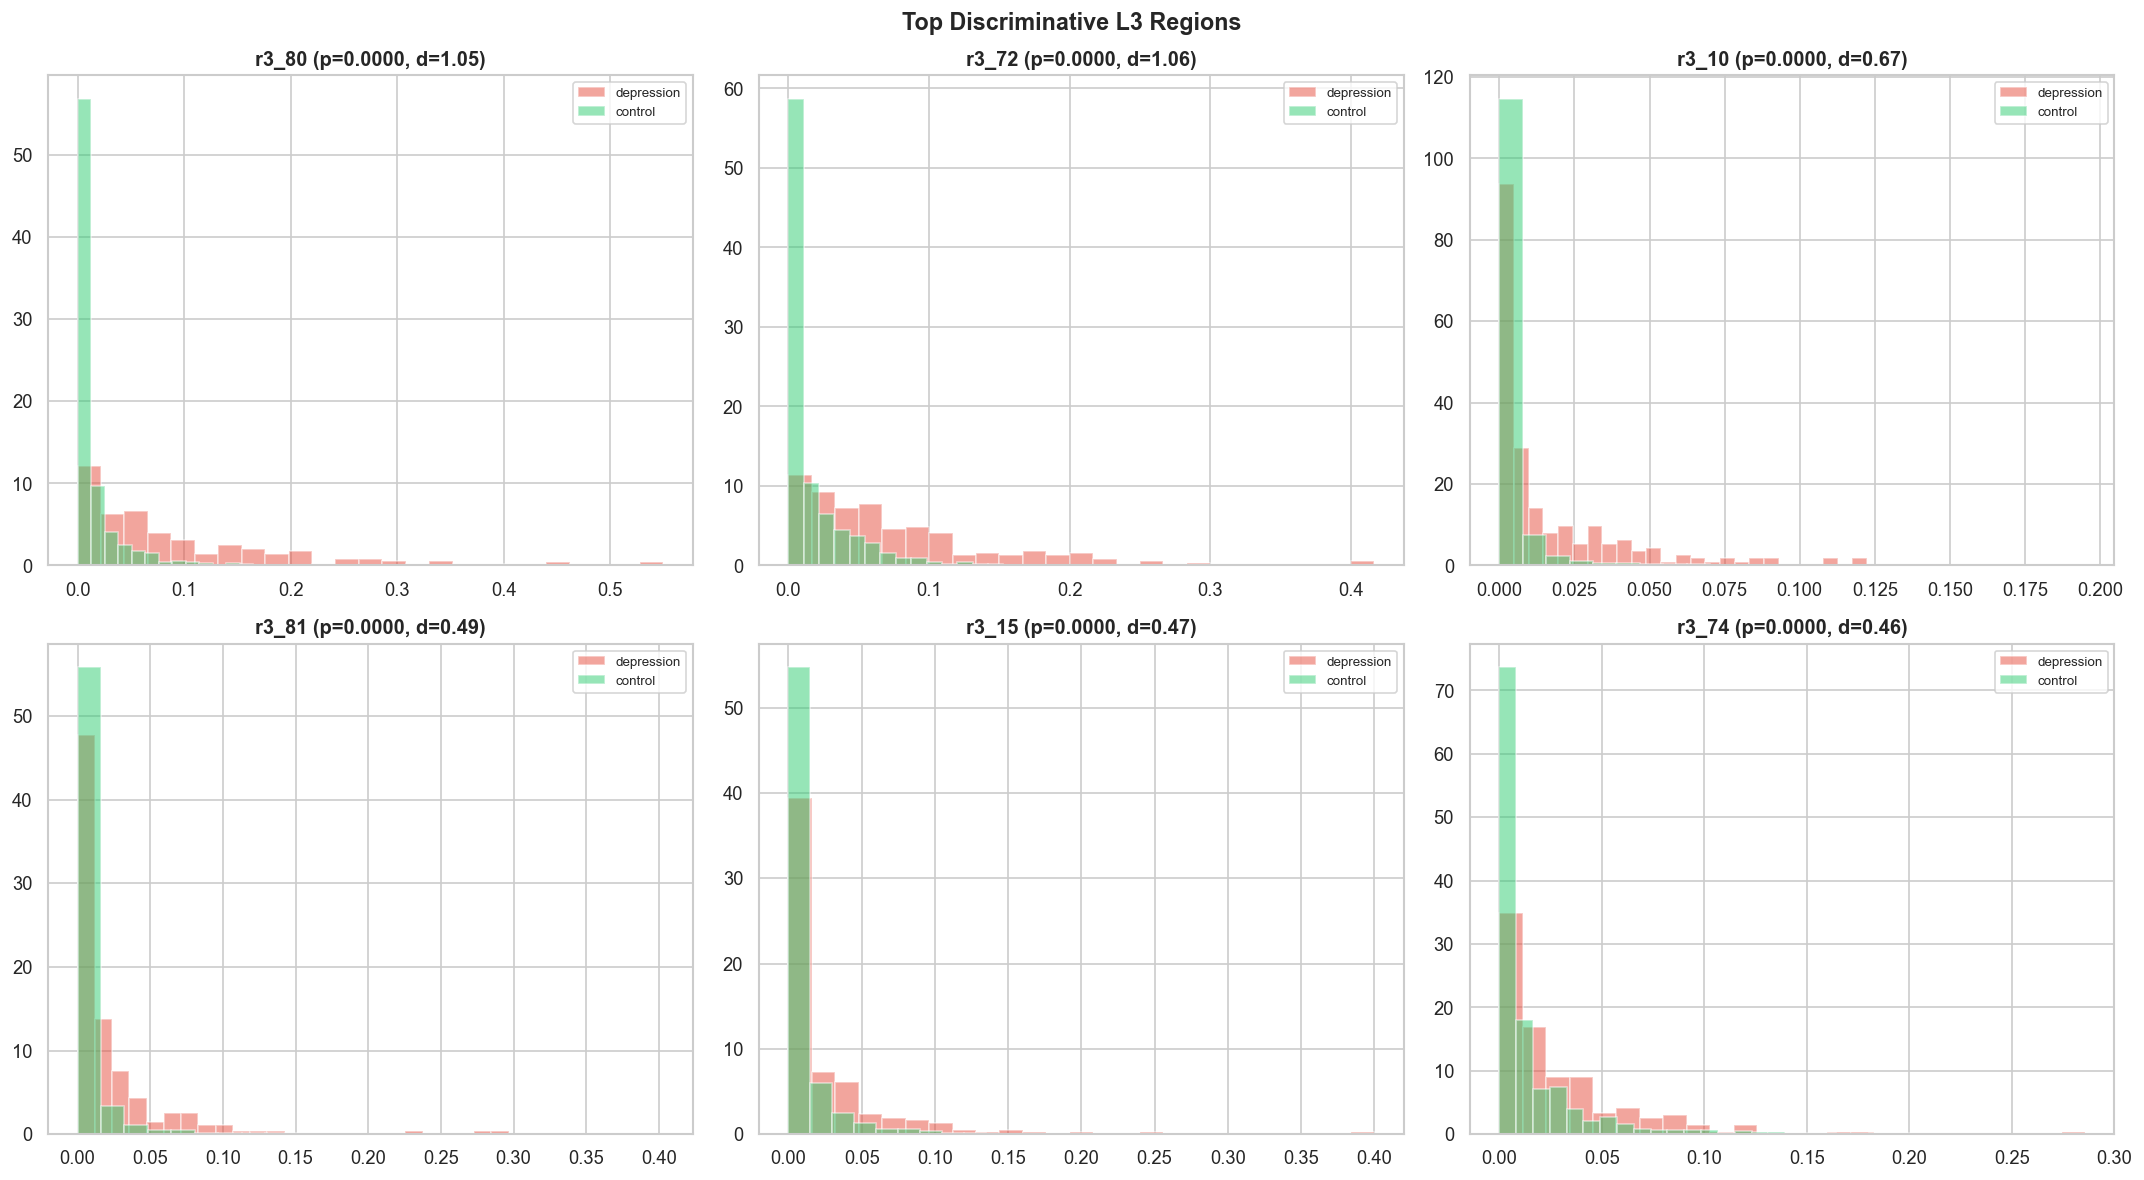

In [13]:
# Visualize: top discriminative L3 regions
top_regions = rpdf.head(6)['region'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, reg in zip(axes.flat, top_regions):
    merged = user_region_dist[[reg]].join(user_info['label'])
    for lab, c in colors.items():
        vals = merged[merged['label']==lab][reg]
        ax.hist(vals, bins=25, alpha=0.5, color=c, label=lab, density=True)
    p = rpdf[rpdf['region']==reg]['p'].values[0]
    d = rpdf[rpdf['region']==reg]['d'].values[0]
    ax.set_title(f'{reg} (p={p:.4f}, d={d:.2f})', fontweight='bold')
    ax.legend(fontsize=8)
fig.suptitle('Top Discriminative L3 Regions', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4. Feature Ablation & Classification

Progressive feature sets, all trained on train split, evaluated on test:
1. Behavioral only (11 features)
2. Static MentalRoBERTa (768)
3. Temporal MentalRoBERTa (768)
4. L3 Region distribution (~60-80)
5. Region + Behavioral
6. Temporal embedding + Behavioral
7. **Full: Temporal embedding + Region + Behavioral**

In [14]:
# Prepare all feature sets
region_cols = [c for c in user_region_dist.columns if c.startswith('r3_')] + ['entropy', 'top3_conc']

# Align all features to same user index
all_users = user_info.index
feat_sets = {
    'behavioral': behav_indexed.reindex(all_users).fillna(0),
    'static_emb': user_mean.reindex(all_users).fillna(0),
    'temporal_emb': user_wmean.reindex(all_users).fillna(0),
    'region_l3': user_region_dist[region_cols].reindex(all_users).fillna(0),
}

experiments = [
    ('Behavioral', ['behavioral']),
    ('Static MentalRoBERTa', ['static_emb']),
    ('Temporal MentalRoBERTa', ['temporal_emb']),
    ('Region L3', ['region_l3']),
    ('Region + Behavioral', ['region_l3', 'behavioral']),
    ('Temporal + Behavioral', ['temporal_emb', 'behavioral']),
    ('Full (Temporal+Region+Behav)', ['temporal_emb', 'region_l3', 'behavioral']),
]

print(f'{"Experiment":<35} {"AUC":>6} {"F1":>6} {"P":>6} {"R":>6} {"dims":>6}')
print('=' * 75)
ablation_results = []

for exp_name, feat_keys in experiments:
    X_all = np.hstack([feat_sets[k].values for k in feat_keys])
    mask_tr = user_info['split'] == 'train'
    mask_te = user_info['split'] == 'test'
    X_tr = X_all[mask_tr]; y_tr = (user_info.loc[mask_tr, 'label']=='depression').astype(int).values
    X_te = X_all[mask_te]; y_te = (user_info.loc[mask_te, 'label']=='depression').astype(int).values

    m, clf, yp, ypred = train_eval(X_tr, y_tr, X_te, y_te, exp_name)
    m['dims'] = X_all.shape[1]
    m['name'] = exp_name
    ablation_results.append(m)

abl_df = pd.DataFrame(ablation_results)
print('\n' + abl_df.to_string(index=False, float_format='%.4f'))

Experiment                             AUC     F1      P      R   dims


  Behavioral: AUC=0.6432 F1=0.0200 P=0.5000 R=0.0102


  Static MentalRoBERTa: AUC=0.9009 F1=0.4571 P=0.7619 R=0.3265


  Temporal MentalRoBERTa: AUC=0.9095 F1=0.4429 P=0.7381 R=0.3163


  Region L3: AUC=0.8898 F1=0.4183 P=0.5818 R=0.3265


  Region + Behavioral: AUC=0.8885 F1=0.2985 P=0.5556 R=0.2041


  Temporal + Behavioral: AUC=0.9068 F1=0.4317 P=0.7317 R=0.3061


  Full (Temporal+Region+Behav): AUC=0.9105 F1=0.4583 P=0.7174 R=0.3367

   AUC     F1  Precision  Recall  dims                         name
0.6432 0.0200     0.5000  0.0102    11                   Behavioral
0.9009 0.4571     0.7619  0.3265   768         Static MentalRoBERTa
0.9095 0.4429     0.7381  0.3163   768       Temporal MentalRoBERTa
0.8898 0.4183     0.5818  0.3265    99                    Region L3
0.8885 0.2985     0.5556  0.2041   110          Region + Behavioral
0.9068 0.4317     0.7317  0.3061   779        Temporal + Behavioral
0.9105 0.4583     0.7174  0.3367   878 Full (Temporal+Region+Behav)


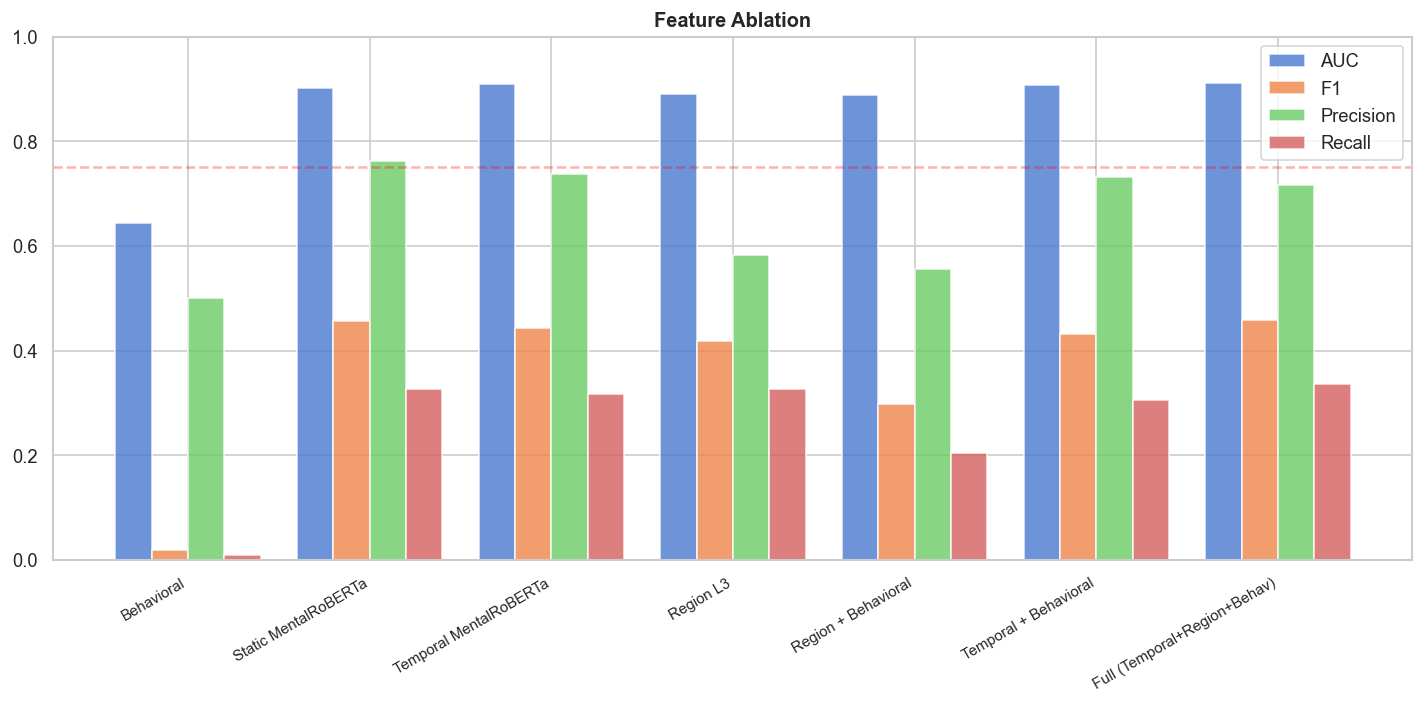

In [15]:
# Ablation bar chart
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(abl_df))
w = 0.2
for i, metric in enumerate(['AUC', 'F1', 'Precision', 'Recall']):
    ax.bar(x + i*w, abl_df[metric], w, label=metric, alpha=0.8)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels(abl_df['name'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1); ax.legend(); ax.axhline(0.75, color='red', linestyle='--', alpha=0.3)
ax.set_title('Feature Ablation', fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Test Evaluation — Best Model with Bootstrap CI

In [16]:
# Best model by F1
best = abl_df.loc[abl_df['F1'].idxmax()]
print(f'Best model: {best["name"]} (F1={best["F1"]:.4f})')

# Re-train best and get bootstrap CI
best_keys = experiments[abl_df['F1'].idxmax()][1]
X_all = np.hstack([feat_sets[k].values for k in best_keys])
mask_tr = user_info['split'] == 'train'
mask_te = user_info['split'] == 'test'

scaler = StandardScaler()
X_tr = scaler.fit_transform(X_all[mask_tr])
y_tr = (user_info.loc[mask_tr, 'label']=='depression').astype(int).values
X_te = scaler.transform(X_all[mask_te])
y_te = (user_info.loc[mask_te, 'label']=='depression').astype(int).values

clf = RandomForestClassifier(n_estimators=300, max_depth=15,
                              class_weight='balanced', random_state=SEED)
clf.fit(X_tr, y_tr)
yp = clf.predict_proba(X_te)[:,1]; ypred = clf.predict(X_te)

ci = bootstrap_ci(y_te, yp, ypred)
print(f'\nTest Results (95% CI, n={N_BOOTSTRAP}):')
for k in ['AUC', 'F1', 'Precision', 'Recall']:
    c = ci[k]
    print(f'  {k:>10}: {c["mean"]:.4f}  [{c["lo"]:.4f}, {c["hi"]:.4f}]')

print(f'\n{classification_report(y_te, ypred, target_names=["control","depression"])}')

Best model: Full (Temporal+Region+Behav) (F1=0.4583)



Test Results (95% CI, n=1000):
         AUC: 0.9107  [0.8746, 0.9413]
          F1: 0.4560  [0.3458, 0.5581]
   Precision: 0.7168  [0.5789, 0.8475]
      Recall: 0.3361  [0.2386, 0.4333]

              precision    recall  f1-score   support

     control       0.95      0.99      0.97      1300
  depression       0.72      0.34      0.46        98

    accuracy                           0.94      1398
   macro avg       0.83      0.66      0.71      1398
weighted avg       0.94      0.94      0.93      1398



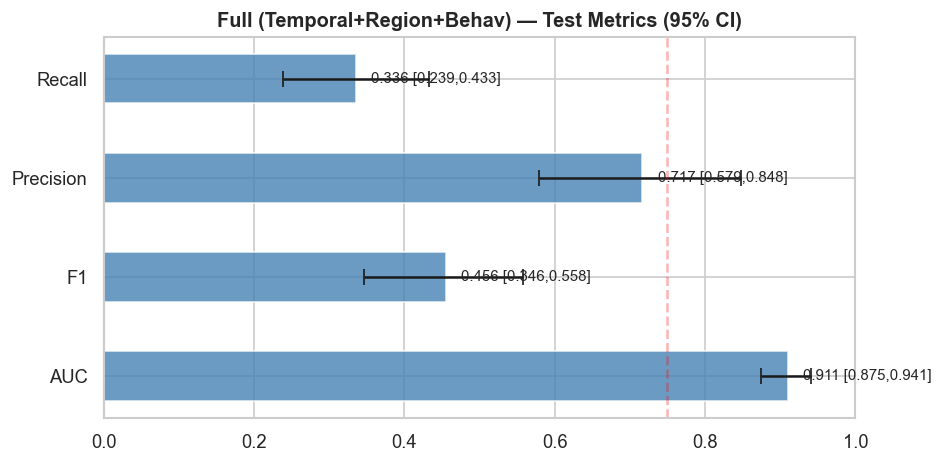

In [17]:
# CI forest plot
fig, ax = plt.subplots(figsize=(8, 4))
ml = ['AUC', 'F1', 'Precision', 'Recall']
means = [ci[m]['mean'] for m in ml]
err = [[ci[m]['mean']-ci[m]['lo'] for m in ml], [ci[m]['hi']-ci[m]['mean'] for m in ml]]
ax.barh(range(4), means, xerr=err, height=0.5, color='steelblue', capsize=5, alpha=0.8)
ax.set_yticks(range(4)); ax.set_yticklabels(ml); ax.set_xlim(0,1)
ax.axvline(0.75, color='red', linestyle='--', alpha=0.3, label='F1≥0.75')
for i, m in enumerate(ml):
    ax.text(ci[m]['mean']+0.02, i, f'{ci[m]["mean"]:.3f} [{ci[m]["lo"]:.3f},{ci[m]["hi"]:.3f}]', va='center', fontsize=9)
ax.set_title(f'{best["name"]} — Test Metrics (95% CI)', fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Early Detection — AUC@k%

Can we detect depression early? For each user, we take the first k% of their posts
and compute features from that prefix only. This simulates sequential monitoring.

In [18]:
# Early detection: AUC as function of % posts observed
percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
early_results = []

for pct in percentages:
    # Take first pct% of each user's posts using cumcount (no apply)
    user_sizes = df.groupby('user_id')['user_id'].transform('size')
    cutoff = (user_sizes * pct / 100).astype(int).clip(lower=1)
    post_idx = df.groupby('user_id').cumcount()
    df_prefix = df[post_idx < cutoff].copy()

    # Recency-weighted embedding on prefix (vectorized)
    w = (df_prefix['t_rel'].values + 0.01).reshape(-1, 1)
    w_embs = df_prefix[emb_cols].values * w
    w_df = pd.DataFrame(w_embs, columns=emb_cols)
    w_df['user_id'] = df_prefix['user_id'].values
    w_df['_w'] = w.ravel()
    user_emb_pct = w_df.groupby('user_id')[emb_cols].sum()
    user_w_total = w_df.groupby('user_id')['_w'].sum()
    user_emb_pct = user_emb_pct.div(user_w_total, axis=0)
    del w_embs, w_df

    # Behavioral on prefix (vectorized)
    pgrp = df_prefix.groupby('user_id')
    behav_pct = pd.DataFrame({
        'n_posts': pgrp.size(),
        'mean_gap': pgrp['gap_seconds'].mean(),
        'std_gap': pgrp['gap_seconds'].std().fillna(0),
        'night_ratio': pgrp['hour_of_day'].apply(lambda h: (h < 6).mean()),
    })
    behav_pct['gap_cv'] = (behav_pct['std_gap'] / behav_pct['mean_gap'].replace(0, 1))
    behav_cols_pct = ['n_posts', 'mean_gap', 'std_gap', 'gap_cv', 'night_ratio']

    # Combine and classify
    common = user_emb_pct.index.intersection(user_info.index).intersection(behav_pct.index)
    X = np.hstack([user_emb_pct.loc[common].values, behav_pct.loc[common][behav_cols_pct].fillna(0).values])
    y = (user_info.loc[common, 'label']=='depression').astype(int).values
    splits = user_info.loc[common, 'split'].values

    mask_tr = splits == 'train'; mask_te = splits == 'test'
    if sum(mask_tr) < 10 or sum(mask_te) < 10: continue

    scaler = StandardScaler()
    clf = RandomForestClassifier(n_estimators=200, max_depth=10,
                                  class_weight='balanced', random_state=SEED)
    clf.fit(scaler.fit_transform(X[mask_tr]), y[mask_tr])
    yp = clf.predict_proba(scaler.transform(X[mask_te]))[:,1]
    auc = roc_auc_score(y[mask_te], yp) if len(np.unique(y[mask_te])) > 1 else 0.5
    early_results.append({'pct': pct, 'AUC': auc, 'n_train': sum(mask_tr), 'n_test': sum(mask_te)})
    print(f'  {pct:>3}% posts → AUC={auc:.4f} (train={sum(mask_tr)}, test={sum(mask_te)})')

early_df = pd.DataFrame(early_results)

   10% posts → AUC=0.8488 (train=716, test=1398)


   20% posts → AUC=0.8584 (train=716, test=1398)


   30% posts → AUC=0.8434 (train=716, test=1398)


   40% posts → AUC=0.8590 (train=716, test=1398)


   50% posts → AUC=0.8882 (train=716, test=1398)


   60% posts → AUC=0.8882 (train=716, test=1398)


   70% posts → AUC=0.8959 (train=716, test=1398)


   80% posts → AUC=0.8878 (train=716, test=1398)


   90% posts → AUC=0.8987 (train=716, test=1398)


  100% posts → AUC=0.9080 (train=716, test=1398)


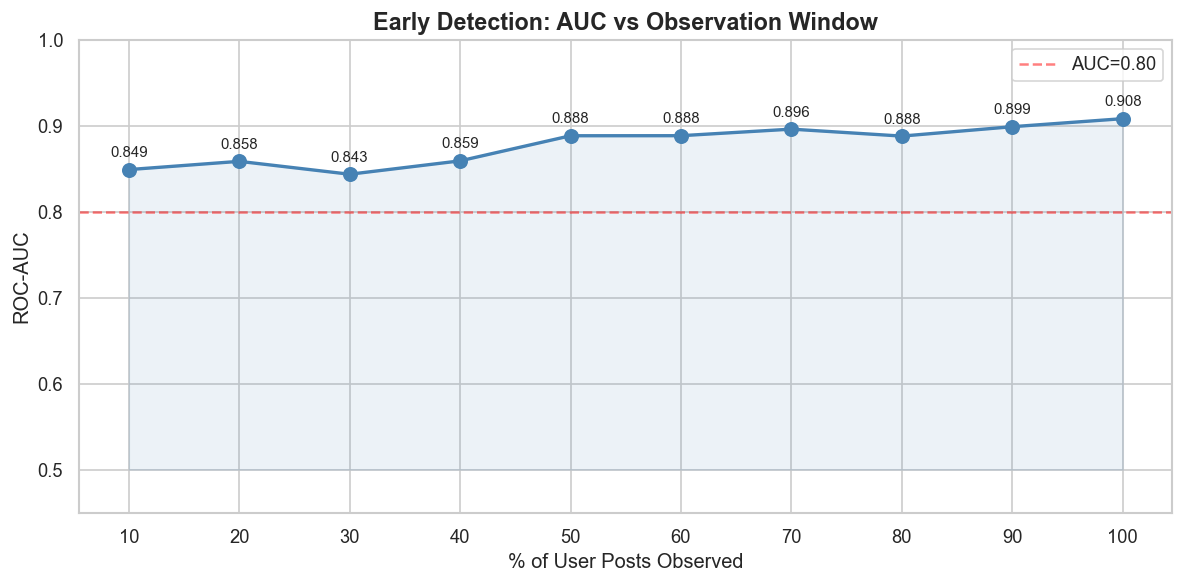


Minimum observation for AUC≥0.80: 10.0% of posts


In [19]:
# ERDE-style curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(early_df['pct'], early_df['AUC'], 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(0.80, color='red', linestyle='--', alpha=0.5, label='AUC=0.80')
ax.fill_between(early_df['pct'], 0.5, early_df['AUC'], alpha=0.1, color='steelblue')
ax.set_xlabel('% of User Posts Observed', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_ylim(0.45, 1.0)
ax.set_xticks(percentages)
ax.legend(fontsize=11)
ax.set_title('Early Detection: AUC vs Observation Window', fontsize=14, fontweight='bold')
for _, row in early_df.iterrows():
    ax.annotate(f'{row["AUC"]:.3f}', (row['pct'], row['AUC']+0.015), ha='center', fontsize=9)
plt.tight_layout(); plt.show()

# Find minimum % for AUC > 0.80
above_80 = early_df[early_df['AUC'] >= 0.80]
if len(above_80) > 0:
    print(f'\nMinimum observation for AUC≥0.80: {above_80.iloc[0]["pct"]}% of posts')
else:
    print(f'\nAUC never reaches 0.80 (max: {early_df["AUC"].max():.4f} at {early_df.loc[early_df["AUC"].idxmax(), "pct"]}%)')

## 7. Summary

In [20]:
# Save results
Path('../results').mkdir(exist_ok=True)
summary = {
    'dataset': 'eRisk',
    'embedding_model': 'mental/mental-roberta-base',
    'dim': DIM,
    'ablation': abl_df.to_dict(orient='records'),
    'best_model': {'name': best['name'], 'ci': ci},
    'early_detection': early_df.to_dict(orient='records'),
}

import json as _json
with open(f'../results/erisk_v2_results.json', 'w') as f:
    _json.dump(summary, f, indent=2, default=str)

print('='*70)
print(f'RESULTS — eRisk (MentalRoBERTa v2)')
print('='*70)
print(f'\nFeature Ablation:')
print(abl_df[['name','AUC','F1','Precision','Recall','dims']].to_string(index=False, float_format='%.4f'))
print(f'\nBest Model: {best["name"]}')
for k in ['AUC','F1','Precision','Recall']:
    c = ci[k]; print(f'  {k:>10}: {c["mean"]:.4f}  [{c["lo"]:.4f}, {c["hi"]:.4f}]')
if len(early_df) > 0:
    print(f'\nEarly Detection:')
    for _, r in early_df.iterrows():
        print(f'  {r["pct"]:>3}% posts → AUC={r["AUC"]:.4f}')
print('='*70)

RESULTS — eRisk (MentalRoBERTa v2)

Feature Ablation:
                        name    AUC     F1  Precision  Recall  dims
                  Behavioral 0.6432 0.0200     0.5000  0.0102    11
        Static MentalRoBERTa 0.9009 0.4571     0.7619  0.3265   768
      Temporal MentalRoBERTa 0.9095 0.4429     0.7381  0.3163   768
                   Region L3 0.8898 0.4183     0.5818  0.3265    99
         Region + Behavioral 0.8885 0.2985     0.5556  0.2041   110
       Temporal + Behavioral 0.9068 0.4317     0.7317  0.3061   779
Full (Temporal+Region+Behav) 0.9105 0.4583     0.7174  0.3367   878

Best Model: Full (Temporal+Region+Behav)
         AUC: 0.9107  [0.8746, 0.9413]
          F1: 0.4560  [0.3458, 0.5581]
   Precision: 0.7168  [0.5789, 0.8475]
      Recall: 0.3361  [0.2386, 0.4333]

Early Detection:


  10.0% posts → AUC=0.8488


  20.0% posts → AUC=0.8584
  30.0% posts → AUC=0.8434
  40.0% posts → AUC=0.8590
  50.0% posts → AUC=0.8882
  60.0% posts → AUC=0.8882
  70.0% posts → AUC=0.8959
  80.0% posts → AUC=0.8878
  90.0% posts → AUC=0.8987
  100.0% posts → AUC=0.9080
